In [1]:
# Installation and setup
%pip install -q librosa soundfile transformers torch-geometric pandas seaborn matplotlib speechbrain torchaudio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Sound separation -> GNN -> reasoning -> storage -> visualization
import os
import json
import glob
import time
import uuid
import datetime
import gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import scipy.signal  # <-- ADDED for Wiener filter and bandpass
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, SAGEConv, BatchNorm
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from speechbrain.inference.separation import SepformerSeparation as separator

# Pipeline root (keep everything within this folder)
PIPELINE_ROOT = Path.cwd()

# 3P separation config (from 3p-test)
SEPFORMER_SOURCE = "speechbrain/sepformer-libri3mix"
SEPFORMER_CHECKPOINT_PATH = os.environ.get(
    "SEPFORMER_CHECKPOINT_PATH",
    str(PIPELINE_ROOT / "final_source_sep_model.pth"),
)
SEPFORMER_HPARAMS_DIR = os.environ.get(
    "SEPFORMER_HPARAMS_DIR",
    str(PIPELINE_ROOT / "pretrained_model_3mix"),
)
SEPARATION_INPUT_DIR = os.environ.get(
    "SEPARATION_INPUT_DIR",
    str(PIPELINE_ROOT / "tse_data" / "test" / "mix"),
)
SEPARATION_OUTPUT_PATH = os.environ.get(
    "SEPARATION_OUTPUT_PATH",
    str(PIPELINE_ROOT / "separated_audios"),
)

# Kaggle reference paths used in 3p-test (keep for reference)
KAGGLE_TSE_BASE_DIR = "/kaggle/working/tse_data"
KAGGLE_INPUT_PATH = "/kaggle/input/notebooks/mathias256/icbhi-coswara-breath/tse_dataset_split"
KAGGLE_SEPFORMER_CHECKPOINT_PATH = "/kaggle/input/notebooks/liamgraphics/new-3p-speechbrain/model_checkpoints/best_audio_separation_model.pt"
KAGGLE_SEPFORMER_HPARAMS_DIR = "/kaggle/working/pretrained_model_3mix"
KAGGLE_SEPARATION_OUTPUT = "/kaggle/working/separated_audios"

# Separation inference settings (from training notebook: 3s chunks, 16kHz)
SEGMENT_SIZE_S = 3.0  # Matches training chunk_duration=3.0
OVERLAP_S = 0.5
MIN_CHUNK_S = 0.5
SEPARATION_SAMPLE_RATE = 16000
RUN_SEPARATION = False

# NEW: Separation preprocessing parameters (matching training notebook)
BANDPASS_LOW = 80.0     # Hz - same as training notebook Cell 5
BANDPASS_HIGH = 4000.0  # Hz - same as training notebook Cell 5
WIENER_ALPHA = 0.85     # Soft mask exponent (from training Cell 6)
WIENER_NPERSEG = 1024   # STFT window size (from training Cell 6)
WIENER_OVERLAP = 768    # STFT overlap (from training Cell 6)

# GNN + pipeline paths (keep within pipeline folder)
GNN_CHECKPOINT_ENV = os.environ.get("GNN_CHECKPOINT_PATH")
GNN_CHECKPOINT_CANDIDATES = [
    "/kaggle/input/models/catherinenassali/gnn-model/pytorch/default/1/best_improved_30epochs_no_earlystop.pt",
    "/kaggle/input/models/catherinenassali/checkpoint/pytorch/default/1/best_improved_30epochs.pt",
    str(PIPELINE_ROOT / "best_improved_30epochs_no_earlystop.pt"),
    str(PIPELINE_ROOT / "best_improved_30epochs.pt"),
]
if GNN_CHECKPOINT_ENV:
    GNN_CHECKPOINT_CANDIDATES = [GNN_CHECKPOINT_ENV] + GNN_CHECKPOINT_CANDIDATES

GNN_CHECKPOINT_PATH = next((p for p in GNN_CHECKPOINT_CANDIDATES if os.path.exists(p)), None)
if GNN_CHECKPOINT_PATH is None:
    raise FileNotFoundError("GNN checkpoint not found. Checked: " + "; ".join(GNN_CHECKPOINT_CANDIDATES))

# Output directories
PIPELINE_OUTPUT = str(PIPELINE_ROOT / "pipeline_results")
GAT_RUNS_DIR = str(PIPELINE_ROOT / "gat_runs")
XAI_OUTPUT_DIR = str(PIPELINE_ROOT / "xai_outputs")  # XAI heatmap output directory

# Create all necessary directories
os.makedirs(SEPARATION_OUTPUT_PATH, exist_ok=True)
os.makedirs(PIPELINE_OUTPUT, exist_ok=True)
os.makedirs(GAT_RUNS_DIR, exist_ok=True)
os.makedirs(XAI_OUTPUT_DIR, exist_ok=True)

device_str = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_str)
print("Device:", device)
print("GNN checkpoint:", GNN_CHECKPOINT_PATH)
print("XAI output directory:", XAI_OUTPUT_DIR)

# ============================================================================
# NEW: Separation preprocessing functions (matching training notebook)
# ============================================================================

def apply_bandpass(waveform, sr, low_hz=BANDPASS_LOW, high_hz=BANDPASS_HIGH):
    """Apply 80-4000 Hz bandpass filter matching training notebook Cell 5."""
    w = torchaudio.functional.highpass_biquad(waveform, sr, cutoff_freq=low_hz)
    w = torchaudio.functional.lowpass_biquad(w, sr, cutoff_freq=high_hz)
    return w

def apply_wiener_filter(est_sources_np, mix_waveform_np, eps=1e-10):
    """
    Wiener filter post-processing matching training notebook Cell 6.
    Uses STFT-based soft masking with alpha exponent.
    """
    stfts = []
    for src in est_sources_np:
        _, _, Zxx = scipy.signal.stft(src, nperseg=WIENER_NPERSEG, noverlap=WIENER_OVERLAP)
        stfts.append(Zxx)
    stfts = np.array(stfts)
    _, _, Zmix = scipy.signal.stft(mix_waveform_np, nperseg=WIENER_NPERSEG, noverlap=WIENER_OVERLAP)
    
    psds = np.abs(stfts) ** 2
    total_psd = np.sum(psds, axis=0) + eps
    refined_sources = []
    
    for i in range(len(est_sources_np)):
        mask = (psds[i] / total_psd) ** WIENER_ALPHA
        refined_spec = mask * Zmix
        _, x_rec = scipy.signal.istft(refined_spec, nperseg=WIENER_NPERSEG, noverlap=WIENER_OVERLAP)
        target_len = len(mix_waveform_np)
        if len(x_rec) > target_len:
            x_rec = x_rec[:target_len]
        else:
            x_rec = np.pad(x_rec, (0, target_len - len(x_rec)))
        # 4th-order Butterworth lowpass at 3800 Hz (from training notebook)
        b, a = scipy.signal.butter(4, 3800.0, btype='low', fs=SEPARATION_SAMPLE_RATE)
        x_rec = scipy.signal.filtfilt(b, a, x_rec)
        refined_sources.append(x_rec)
    
    return np.array(refined_sources)

def preprocess_and_separate(mix, fs, model):
    """
    Full preprocessing + separation + postprocessing pipeline
    matching the training notebook's Cell 5 (bandpass) and Cell 6 (Wiener filter).
    
    Args:
        mix: torch.Tensor of shape (channels, samples)
        fs: original sample rate
        model: SepFormer separation model
    
    Returns:
        refined: torch.Tensor of shape (3, samples) - separated sources
        fs_out: final sample rate (always 16kHz)
        mix_np: numpy version of preprocessed mix (for Wiener filter)
    """
    # 1. Convert to mono
    if mix.shape[0] > 1:
        mix = mix.mean(0, keepdim=True)
    
    # 2. Resample to 16 kHz if needed
    if fs != SEPARATION_SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(orig_freq=fs, new_freq=SEPARATION_SAMPLE_RATE)
        mix = resampler(mix)
        fs = SEPARATION_SAMPLE_RATE
    
    # 3. Bandpass filter (80-4000 Hz) matching training Cell 5
    mix = apply_bandpass(mix, fs)
    
    sig_len = mix.shape[1]
    seg_len = int(SEGMENT_SIZE_S * fs)
    step = int((SEGMENT_SIZE_S - OVERLAP_S) * fs)
    
    # 4. Run separation with overlap-add
    combined_est = torch.zeros(3, sig_len)
    window_count = torch.zeros(1, sig_len)
    mix_np = mix.squeeze(0).cpu().numpy()
    
    for start in range(0, sig_len, step):
        end = min(start + seg_len, sig_len)
        chunk = mix[:, start:end]
        if chunk.shape[1] < fs * MIN_CHUNK_S:
            continue
        est_chunk = model.separate_batch(chunk.to(device))
        for s_idx in range(3):
            combined_est[s_idx, start:end] += est_chunk[0, :, s_idx].cpu()
        window_count[0, start:end] += 1.0
        del est_chunk
        torch.cuda.empty_cache()
    
    combined_est /= window_count.clamp(min=1.0)
    
    # 5. Apply Wiener filter post-processing (matching training Cell 6)
    combined_est_np = combined_est.cpu().numpy()
    refined_np = apply_wiener_filter(combined_est_np, mix_np)
    refined = torch.from_numpy(refined_np).float()
    
    return refined, fs, mix_np

def load_separation_model():
    """Load SepFormer model with improved checkpoint loading logic."""
    print("Initializing separation model...")
    model = separator.from_hparams(
        source=SEPFORMER_SOURCE,
        savedir=SEPFORMER_HPARAMS_DIR,
        run_opts={"device": device_str},
    )
    print("Loading separation checkpoint...")
    checkpoint = torch.load(SEPFORMER_CHECKPOINT_PATH, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    new_state_dict = {k[6:] if k.startswith("model.") else k: v for k, v in state_dict.items()}
    
    # Try strict loading first for better diagnostics
    try:
        model.mods.load_state_dict(new_state_dict, strict=True)
        print("  -> Checkpoint loaded with strict=True (all keys matched)")
    except Exception as e:
        print(f"  -> Warning: strict loading failed: {str(e)[:120]}")
        print("  -> Falling back to strict=False")
        model.mods.load_state_dict(new_state_dict, strict=False)
    
    model.mods.eval()
    print("  -> SepFormer ready for inference")
    return model

def run_separation_on_folder(mix_folder, output_folder, model):
    """Run separation on all mix files in a folder using the unified preprocessing pipeline."""
    mix_files = sorted(glob.glob(os.path.join(mix_folder, "*.wav")))
    if len(mix_files) == 0:
        raise FileNotFoundError("No mix files found in: " + mix_folder)

    print("Separating", len(mix_files), "files")
    print(f"  Using: {SEGMENT_SIZE_S}s chunks, bandpass {BANDPASS_LOW}-{BANDPASS_HIGH}Hz, Wiener filter alpha={WIENER_ALPHA}")
    
    with torch.no_grad():
        for mix_path in mix_files:
            mix_filename = os.path.basename(mix_path)
            base_id = mix_filename.replace("_mix.wav", "").replace(".wav", "")

            mix, fs = torchaudio.load(mix_path)
            
            # Run full preprocessing + separation + postprocessing
            refined, fs_out, _ = preprocess_and_separate(mix, fs, model)

            for s_idx in range(3):
                out_name = f"{base_id}_s{s_idx + 1}_est.wav"
                out_path = os.path.join(output_folder, out_name)
                torchaudio.save(out_path, refined[s_idx:s_idx + 1], fs_out)

            del refined, mix
            gc.collect()

if RUN_SEPARATION:
    if not os.path.exists(SEPFORMER_CHECKPOINT_PATH):
        raise FileNotFoundError("Separation checkpoint not found: " + SEPFORMER_CHECKPOINT_PATH)
    sep_model = load_separation_model()
    run_separation_on_folder(SEPARATION_INPUT_DIR, SEPARATION_OUTPUT_PATH, sep_model)

# ============================================================================
# GNN Model Definition (unchanged from original)
# ============================================================================

class ImprovedRespiratoryGAT(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=4, num_heads=4, dropout=0.4):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(num_layers):
            if i % 2 == 0:
                conv = GATConv(hidden_dim, max(1, hidden_dim // num_heads), heads=num_heads, concat=True, dropout=dropout)
            else:
                conv = SAGEConv(hidden_dim, hidden_dim)
            self.gat_layers.append(conv)
            self.norms.append(BatchNorm(hidden_dim))
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim, max(4, hidden_dim // 4)),
            nn.Tanh(),
            nn.Linear(max(4, hidden_dim // 4), 1),
        )
        self.wheeze_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )
        self.crackle_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )
        self.log_var_wheeze = nn.Parameter(torch.tensor(0.0))
        self.log_var_crackle = nn.Parameter(torch.tensor(0.0))
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, "batch") else None

        x = x.to(self.input_proj[0].weight.device)
        edge_index = edge_index.to(self.input_proj[0].weight.device)

        x = self.input_proj(x)
        residuals = []
        for i, (conv, norm) in enumerate(zip(self.gat_layers, self.norms)):
            x_new = conv(x, edge_index)
            x_new = F.elu(x_new)
            x_new = norm(x_new)
            if i > 0 and i % 2 == 0:
                x_new = x_new + residuals[-1]
            x = F.dropout(x_new, p=self.dropout, training=self.training)
            residuals.append(x)

        if batch is not None:
            batch = batch.to(x.device)
            attn_scores = self.attention_pool(x).squeeze(-1)
            x_graph = []
            for b in torch.unique(batch):
                mask = batch == b
                scores = attn_scores[mask]
                weights = torch.softmax(scores, dim=0).unsqueeze(-1)
                x_graph.append((x[mask] * weights).sum(dim=0))
            x = torch.stack(x_graph, dim=0)
        else:
            attn_scores = self.attention_pool(x).squeeze(-1)
            weights = torch.softmax(attn_scores, dim=0).unsqueeze(-1)
            x = (x * weights).sum(dim=0, keepdim=True)

        w_logits = self.wheeze_head(x).squeeze(-1)
        c_logits = self.crackle_head(x).squeeze(-1)
        return w_logits, c_logits

def load_gnn_model(checkpoint_path, device):
    model = ImprovedRespiratoryGAT(input_dim=768, hidden_dim=256, num_layers=4, num_heads=4, dropout=0.4)
    model = model.to(device)
    if os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=device)
        if "model_state_dict" in state_dict:
            state_dict = state_dict["model_state_dict"]
        elif "state_dict" in state_dict:
            state_dict = state_dict["state_dict"]
        new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict, strict=False)
        print("Loaded GNN checkpoint:", checkpoint_path)
    else:
        raise FileNotFoundError("GNN checkpoint not found: " + checkpoint_path)
    model.eval()
    return model

# ============================================================================
# Patient State Manager (unchanged from original)
# ============================================================================

class PatientStateManager:
    def __init__(self, ema_alpha=0.12, low_delta=0.08, high_delta=0.20, min_samples_for_baseline=5, force_established_after_s=10.0):
        self.ema_alpha = ema_alpha
        self.low_delta = low_delta
        self.high_delta = high_delta
        self.min_samples_for_baseline = min_samples_for_baseline
        self.force_established_after_s = force_established_after_s
        self.patient_data = {}

    def update_and_get_state(self, patient_id, wheeze_prob, crackle_prob, timestamp=0.0):
        if patient_id not in self.patient_data:
            self.patient_data[patient_id] = {
                "wheeze_ema": wheeze_prob,
                "crackle_ema": crackle_prob,
                "wheeze_baseline": None,
                "crackle_baseline": None,
                "wheeze_history": [],
                "crackle_history": [],
                "timestamps": [],
                "count": 0,
                "baseline_established": False,
            }

        data = self.patient_data[patient_id]
        data["timestamps"].append(timestamp)
        data["wheeze_history"].append(wheeze_prob)
        data["crackle_history"].append(crackle_prob)
        data["count"] += 1

        if data["count"] == 1:
            data["wheeze_ema"] = wheeze_prob
            data["crackle_ema"] = crackle_prob
        else:
            data["wheeze_ema"] = (self.ema_alpha * wheeze_prob + (1 - self.ema_alpha) * data["wheeze_ema"])
            data["crackle_ema"] = (self.ema_alpha * crackle_prob + (1 - self.ema_alpha) * data["crackle_ema"])

        if data["count"] >= self.min_samples_for_baseline and not data["baseline_established"]:
            data["wheeze_baseline"] = float(np.mean(data["wheeze_history"][-self.min_samples_for_baseline :]))
            data["crackle_baseline"] = float(np.mean(data["crackle_history"][-self.min_samples_for_baseline :]))
            data["baseline_established"] = True

        result = {"overall_state": "establishing", "reason": {}}
        for axis, ema, baseline, history in [
            ("wheeze", data["wheeze_ema"], data["wheeze_baseline"], data["wheeze_history"]),
            ("crackle", data["crackle_ema"], data["crackle_baseline"], data["crackle_history"]),
        ]:
            if not data["baseline_established"] or baseline is None:
                state = "establishing"
                delta = 0.0
                trend = 0.0
            else:
                delta = float(ema - baseline)
                trend = float(history[-1] - history[-3]) if len(history) >= 3 else 0.0
                if abs(delta) < self.low_delta:
                    state = "green"
                elif abs(delta) < self.high_delta:
                    state = "orange"
                else:
                    state = "red"

            result["reason"][axis] = {
                "baseline": baseline,
                "value": ema,
                "delta": delta,
                "trend": trend,
                "state": state,
            }

        if timestamp >= self.force_established_after_s and not data["baseline_established"] and data["count"] > 0:
            data["baseline_established"] = True
            data["wheeze_baseline"] = float(np.mean(data["wheeze_history"]))
            data["crackle_baseline"] = float(np.mean(data["crackle_history"]))
            for axis in ["wheeze", "crackle"]:
                result["reason"][axis]["baseline"] = data["%s_baseline" % axis]
                result["reason"][axis]["state"] = "green"

        states = [result["reason"][axis]["state"] for axis in ["wheeze", "crackle"]]
        for s in ["red", "orange", "green", "establishing"]:
            if s in states:
                result["overall_state"] = s
                break

        result["count"] = data["count"]
        return result

# Load GNN model
gnn_model = load_gnn_model(GNN_CHECKPOINT_PATH, device)
gnn_model.eval()

# ============================================================================
# Wav2Vec2 Setup (feature extractor) - unchanged
# ============================================================================

print("Loading Wav2Vec2...")
wav2vec_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model.eval()
wav2vec_model = wav2vec_model.to(device)

FRAME_SECONDS = 0.5
SR = 16000
FRAME_LEN = int(FRAME_SECONDS * SR)

def build_chain_edge_index(n):
    edges = []
    for i in range(n - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])
    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

def estimate_breathing_rate_bpm(y, sr, audio_duration_s):
    if len(y) < sr:
        return None
    frame_len = int(0.2 * sr)
    hop_len = int(0.05 * sr)
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop_len)[0]
    if len(rms) == 0:
        return None
    win = 5
    if len(rms) >= win:
        smooth = np.convolve(rms, np.ones(win) / win, mode="same")
    else:
        smooth = rms
    thr = float(smooth.mean() + 0.5 * smooth.std())
    times = librosa.frames_to_time(np.arange(len(smooth)), sr=sr, hop_length=hop_len)
    min_interval = 0.8
    peaks = []
    last_t = -1e9
    for i in range(1, len(smooth) - 1):
        if smooth[i] > smooth[i - 1] and smooth[i] >= smooth[i + 1] and smooth[i] > thr:
            t = float(times[i])
            if t - last_t >= min_interval:
                peaks.append(t)
                last_t = t
    if len(peaks) < 2:
        return None
    bpm = (len(peaks) / max(audio_duration_s, 1e-6)) * 60.0
    return float(bpm)

# ============================================================================
# XAI Functions (PRESERVED - unchanged from your working version)
# ============================================================================

def integrated_gradients_nodes(model, data, target="wheeze", steps=20):
    model.eval()
    x = data.x.detach()
    baseline = torch.zeros_like(x)
    grads_sum = torch.zeros_like(x)
    for alpha in np.linspace(0.0, 1.0, steps):
        x_scaled = (baseline + alpha * (x - baseline)).detach().requires_grad_(True)
        d = Data(x=x_scaled, edge_index=data.edge_index)
        w_logits, c_logits = model(d)
        out = w_logits if target == "wheeze" else c_logits
        out_scalar = out.view(-1)[0]
        grad = torch.autograd.grad(out_scalar, x_scaled, retain_graph=False, create_graph=False)[0]
        grads_sum += grad
    avg_grads = grads_sum / float(steps)
    attributions = (x - baseline) * avg_grads
    node_attr = attributions.detach().cpu().norm(p=2, dim=1).numpy()
    return node_attr

def grad_times_input_nodes(model, data, target="wheeze"):
    model.eval()
    x = data.x.detach().clone().requires_grad_(True)
    d = Data(x=x, edge_index=data.edge_index)
    w_logits, c_logits = model(d)
    out = w_logits if target == "wheeze" else c_logits
    out_scalar = out.view(-1)[0]
    grad = torch.autograd.grad(out_scalar, x, retain_graph=False, create_graph=False)[0]
    gxi = (grad * x).detach().cpu().norm(p=2, dim=1).numpy()
    return gxi

def topk_indices(arr, k):
    if arr is None or len(arr) == 0:
        return []
    k = min(int(k), len(arr))
    return [int(i) for i in np.argsort(arr)[-k:][::-1]]

def list_to_csv_value(v):
    if not v:
        return ""
    return ";".join(str(x) for x in v)

Device: cuda
GNN checkpoint: /kaggle/input/models/catherinenassali/gnn-model/pytorch/default/1/best_improved_30epochs_no_earlystop.pt
XAI output directory: /kaggle/working/xai_outputs
Loaded GNN checkpoint: /kaggle/input/models/catherinenassali/gnn-model/pytorch/default/1/best_improved_30epochs_no_earlystop.pt
Loading Wav2Vec2...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
# Run audio separation first using selected eval mix files (no zip extraction)

KAGGLE_ROOT = "/kaggle/input/notebooks/mathias256/3p-speechbrain"
KAGGLE_SEPFORMER_HPARAMS = "/kaggle/working/pretrained_model_3mix"

EVAL_MIX_DIR = os.path.join(KAGGLE_ROOT, "tse_data", "eval", "mix")
OUTPUT_FOLDER = "/kaggle/working/separated_audios"

SELECTED_MIX_FILES = [
    os.path.join(EVAL_MIX_DIR, "sample_104_mix.wav"),
    os.path.join(EVAL_MIX_DIR, "sample_117_mix.wav"),
    os.path.join(EVAL_MIX_DIR, "sample_120_mix.wav"),
]

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(KAGGLE_SEPFORMER_HPARAMS, exist_ok=True)

# Update globals used by the GNN cell
SEPARATION_INPUT_DIR = EVAL_MIX_DIR
SEPARATION_OUTPUT_PATH = OUTPUT_FOLDER
RUN_SEPARATION = True

KAGGLE_SEPFORMER_CKPT_CANDIDATES = [
    "/kaggle/input/notebooks/liamgraphics/new-3p-speechbrain/model_checkpoints/best_audio_separation_model.pt",
    "/kaggle/input/notebooks/liamgraphics/new-3p-speechbrain/model_checkpoints/latest_checkpoint.pt",
    "/kaggle/working/model_checkpoints/best_audio_separation_model.pt",
    os.path.join(KAGGLE_ROOT, "model_checkpoints", "best_audio_separation_model.pt"),
    os.path.join(KAGGLE_ROOT, "final_source_sep_model.pth"),
]
KAGGLE_SEPFORMER_CKPT = next((p for p in KAGGLE_SEPFORMER_CKPT_CANDIDATES if os.path.exists(p)), None)
if KAGGLE_SEPFORMER_CKPT:
    SEPFORMER_CHECKPOINT_PATH = KAGGLE_SEPFORMER_CKPT
    print("Using SepFormer checkpoint:", KAGGLE_SEPFORMER_CKPT)
SEPFORMER_HPARAMS_DIR = KAGGLE_SEPFORMER_HPARAMS

if not os.path.exists(SEPFORMER_CHECKPOINT_PATH):
    raise FileNotFoundError("Separation checkpoint not found: " + SEPFORMER_CHECKPOINT_PATH)

mix_files = [p for p in SELECTED_MIX_FILES if os.path.exists(p)]
if not mix_files:
    raise FileNotFoundError("No selected mix files found under: " + EVAL_MIX_DIR)

def run_separation_on_files(mix_files, output_folder, model):
    print("Separating", len(mix_files), "files")
    with torch.no_grad():
        for mix_path in mix_files:
            if not os.path.exists(mix_path):
                print("Skipping missing:", mix_path)
                continue
            mix_filename = os.path.basename(mix_path)
            base_id = mix_filename.replace("_mix.wav", "").replace(".wav", "")

            mix, fs = torchaudio.load(mix_path)
            if mix.shape[0] > 1:
                mix = mix.mean(0, keepdim=True)

            sig_len = mix.shape[1]
            seg_len = int(SEGMENT_SIZE_S * fs)
            step = int((SEGMENT_SIZE_S - OVERLAP_S) * fs)

            combined_est = torch.zeros(3, sig_len)
            window_count = torch.zeros(1, sig_len)

            for start in range(0, sig_len, step):
                end = min(start + seg_len, sig_len)
                chunk = mix[:, start:end]
                if chunk.shape[1] < fs * MIN_CHUNK_S:
                    continue
                est_chunk = model.separate_batch(chunk.to(device))
                for s_idx in range(3):
                    combined_est[s_idx, start:end] += est_chunk[0, :, s_idx].cpu()
                window_count[0, start:end] += 1.0
                del est_chunk
                torch.cuda.empty_cache()

            combined_est /= window_count.clamp(min=1.0)

            for s_idx in range(3):
                out_name = "%s_s%d_est.wav" % (base_id, s_idx + 1)
                out_path = os.path.join(output_folder, out_name)
                torchaudio.save(out_path, combined_est[s_idx : s_idx + 1], fs)

            del combined_est, window_count, mix
            gc.collect()

print("Separation inputs:", mix_files)
sep_model = load_separation_model()
run_separation_on_files(mix_files, SEPARATION_OUTPUT_PATH, sep_model)
print("Separated files saved to:", SEPARATION_OUTPUT_PATH)
print("Separated preview:", sorted(glob.glob(os.path.join(SEPARATION_OUTPUT_PATH, "*.wav")))[:6])

Using SepFormer checkpoint: /kaggle/input/notebooks/liamgraphics/new-3p-speechbrain/model_checkpoints/best_audio_separation_model.pt
Separation inputs: ['/kaggle/input/notebooks/mathias256/3p-speechbrain/tse_data/eval/mix/sample_104_mix.wav', '/kaggle/input/notebooks/mathias256/3p-speechbrain/tse_data/eval/mix/sample_117_mix.wav', '/kaggle/input/notebooks/mathias256/3p-speechbrain/tse_data/eval/mix/sample_120_mix.wav']
Initializing separation model...


hyperparams.yaml: 0.00B [00:00, ?B/s]

encoder.ckpt:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

masknet.ckpt:   0%|          | 0.00/113M [00:00<?, ?B/s]

decoder.ckpt:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Loading separation checkpoint...
  -> Checkpoint loaded with strict=True (all keys matched)
  -> SepFormer ready for inference
Separating 3 files
Separated files saved to: /kaggle/working/separated_audios
Separated preview: ['/kaggle/working/separated_audios/sample_104_s1_est.wav', '/kaggle/working/separated_audios/sample_104_s2_est.wav', '/kaggle/working/separated_audios/sample_104_s3_est.wav', '/kaggle/working/separated_audios/sample_117_s1_est.wav', '/kaggle/working/separated_audios/sample_117_s2_est.wav', '/kaggle/working/separated_audios/sample_117_s3_est.wav']


In [4]:
# GNN + reasoning pipeline over separated audio outputs
import csv

compute_attributions = True
attribution_target = "wheeze"
integrated_steps = 20
attr_topk = 3
window_seconds = 5.0

def find_audio_files(audio_root):
    files = []
    for ext in ("*.wav", "*.mp3", "*.flac"):
        files.extend(glob.glob(os.path.join(audio_root, ext)))
    return sorted(files)

def detect_source_from_name(base_name):
    name = base_name.lower()
    if "_s1" in name or name.endswith("_s1") or "source1" in name:
        return "source_1"
    if "_s2" in name or name.endswith("_s2") or "source2" in name:
        return "source_2"
    if "_s3" in name or name.endswith("_s3") or "source3" in name:
        return "source_3"
    return "unknown"

def infer_on_audio_file(audio_path, model, checkpoint_name):
    y, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    audio_duration_s = float(len(y) / SR)

    frames = []
    for i in range(0, len(y), FRAME_LEN):
        f = y[i:i + FRAME_LEN]
        if len(f) < FRAME_LEN:
            f = np.pad(f, (0, FRAME_LEN - len(f)), mode="constant")
        frames.append(f.astype(np.float32))

    if len(frames) == 0:
        print("No frames extracted; skipping", audio_path)
        return None

    embeddings = []
    batch_size = 8
    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch = frames[i:i + batch_size]
            inputs = wav2vec_processor(batch, sampling_rate=SR, return_tensors="pt", padding=True)
            input_values = inputs.input_values.to(device)
            out = wav2vec_model(input_values)
            emb = out.last_hidden_state.mean(dim=1).cpu().numpy().astype(np.float32)
            embeddings.append(emb)

    X = np.concatenate(embeddings, axis=0) if len(embeddings) else np.zeros((0, 768), dtype=np.float32)
    if X.shape[0] == 0:
        print("No embeddings computed; skipping", audio_path)
        return None

    edge_index = build_chain_edge_index(X.shape[0])
    data = Data(x=torch.tensor(X, dtype=torch.float32), edge_index=edge_index)

    start = time.time()
    with torch.no_grad():
        data = data.to(device)
        w_logits, c_logits = model(data)
    infer_ms = (time.time() - start) * 1000.0

    w_prob = float(torch.sigmoid(w_logits).view(-1)[0].cpu().item())
    c_prob = float(torch.sigmoid(c_logits).view(-1)[0].cpu().item())
    w_thr = 0.5
    c_thr = 0.5
    w_pred = int(w_prob >= w_thr)
    c_pred = int(c_prob >= c_thr)

    w_unc = None
    c_unc = None
    w_conf = None
    c_conf = None
    if hasattr(model, "log_var_wheeze"):
        w_logvar = float(model.log_var_wheeze.detach().cpu().item())
        w_unc = float(np.exp(0.5 * w_logvar))
        w_conf = float(1.0 / (1.0 + w_unc))
    if hasattr(model, "log_var_crackle"):
        c_logvar = float(model.log_var_crackle.detach().cpu().item())
        c_unc = float(np.exp(0.5 * c_logvar))
        c_conf = float(1.0 / (1.0 + c_unc))

    breathing_rate_bpm = estimate_breathing_rate_bpm(y, SR, audio_duration_s)

    state_mgr = PatientStateManager(
        ema_alpha=0.12,
        low_delta=0.08,
        high_delta=0.20,
        min_samples_for_baseline=5,
        force_established_after_s=10.0,
    )

    frames_per_window = max(1, int(round(window_seconds / FRAME_SECONDS)))
    window_rows = []

    for w_start in range(0, X.shape[0], frames_per_window):
        Xw = X[w_start:w_start + frames_per_window]
        if Xw.shape[0] == 0:
            continue
        ew = build_chain_edge_index(Xw.shape[0])
        dw = Data(x=torch.tensor(Xw, dtype=torch.float32), edge_index=ew)

        with torch.no_grad():
            dw = dw.to(device)
            w_l, c_l = model(dw)

        w_p = float(torch.sigmoid(w_l).view(-1)[0].cpu().item())
        c_p = float(torch.sigmoid(c_l).view(-1)[0].cpu().item())
        w_pd = int(w_p >= w_thr)
        c_pd = int(c_p >= c_thr)

        start_sec = float(w_start * FRAME_SECONDS)
        end_sec = float(min((w_start + Xw.shape[0]) * FRAME_SECONDS, audio_duration_s))

        start_sample = int(start_sec * SR)
        end_sample = int(end_sec * SR)
        y_window = y[start_sample:end_sample] if end_sample > start_sample else np.array([], dtype=np.float32)
        win_duration = max(end_sec - start_sec, 1e-6)
        breathing_rate_window = estimate_breathing_rate_bpm(y_window, SR, win_duration)

        state_out = state_mgr.update_and_get_state(Path(audio_path).stem, w_p, c_p, timestamp=start_sec)
        patient_state = state_out.get("overall_state")

        ig_topk = []
        gxi_topk = []
        if compute_attributions:
            try:
                ig_scores = integrated_gradients_nodes(model, dw, target=attribution_target, steps=integrated_steps)
                gxi_scores = grad_times_input_nodes(model, dw, target=attribution_target)
                ig_topk = topk_indices(ig_scores, attr_topk)
                gxi_topk = topk_indices(gxi_scores, attr_topk)
            except Exception as e:
                print("Attribution failed for window", start_sec, "->", end_sec, "error:", e)

        window_rows.append({
            "start_sec": round(start_sec, 3),
            "end_sec": round(end_sec, 3),
            "num_frames": int(Xw.shape[0]),
            "wheeze_prob": round(w_p, 4),
            "crackle_prob": round(c_p, 4),
            "wheeze_pred": int(w_pd),
            "crackle_pred": int(c_pd),
            "patient_state": patient_state,
            "breathing_rate_bpm": None if breathing_rate_window is None else round(breathing_rate_window, 2),
            "ig_topk": ig_topk,
            "gxi_topk": gxi_topk,
        })

    if len(window_rows) > 0:
        w_win_probs = np.array([r["wheeze_prob"] for r in window_rows], dtype=np.float32)
        c_win_probs = np.array([r["crackle_prob"] for r in window_rows], dtype=np.float32)
        w_win_pred = np.array([r["wheeze_pred"] for r in window_rows], dtype=np.int32)
        c_win_pred = np.array([r["crackle_pred"] for r in window_rows], dtype=np.int32)
        win_summary = {
            "window_seconds": float(window_seconds),
            "frame_seconds": float(FRAME_SECONDS),
            "num_windows": int(len(window_rows)),
            "frames_per_window": int(frames_per_window),
            "wheeze_window_positive": int(w_win_pred.sum()),
            "crackle_window_positive": int(c_win_pred.sum()),
            "wheeze_window_ratio": float(w_win_pred.mean()),
            "crackle_window_ratio": float(c_win_pred.mean()),
            "wheeze_prob_mean_window": float(w_win_probs.mean()),
            "crackle_prob_mean_window": float(c_win_probs.mean()),
            "wheeze_prob_max_window": float(w_win_probs.max()),
            "crackle_prob_max_window": float(c_win_probs.max()),
        }
    else:
        win_summary = {
            "window_seconds": float(window_seconds),
            "frame_seconds": float(FRAME_SECONDS),
            "num_windows": 0,
            "frames_per_window": int(frames_per_window),
        }

    short_audio = audio_duration_s < FRAME_SECONDS
    near_threshold = (abs(w_prob - w_thr) <= 0.02) or (abs(c_prob - c_thr) <= 0.02)

    request_id = uuid.uuid4().hex
    now_utc = datetime.datetime.now(datetime.timezone.utc)
    timestamp = now_utc.strftime("%Y-%m-%dT%H:%M:%SZ")

    output = {
        "request_id": request_id,
        "timestamp": timestamp,
        "result": {
            "audio_id": Path(audio_path).stem,
            "audio_duration_s": round(audio_duration_s, 3),
            "wheeze": {
                "probability": round(w_prob, 4),
                "prediction": bool(w_pred),
                "confidence": None if w_conf is None else round(w_conf, 4),
            },
            "crackle": {
                "probability": round(c_prob, 4),
                "prediction": bool(c_pred),
                "confidence": None if c_conf is None else round(c_conf, 4),
            },
            "breathing_rate_bpm": None if breathing_rate_bpm is None else round(breathing_rate_bpm, 2),
            "model_version": Path(checkpoint_name).name,
            "inference_time_ms": round(float(infer_ms), 2),
        },
        "reasoning": {
            "thresholds": {"wheeze": w_thr, "crackle": c_thr},
            "uncertainty_std": {"wheeze": w_unc, "crackle": c_unc},
            "flags": {"short_audio": bool(short_audio), "near_threshold": bool(near_threshold)},
            "cumulative_windows": win_summary,
        },
    }

    run_root = Path(GAT_RUNS_DIR)
    run_id = now_utc.strftime("%Y%m%dT%H%M%SZ") + "_" + Path(audio_path).stem + "_" + request_id[:8]
    run_dir = run_root / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    with open(run_dir / "result.json", "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2)

    with open(run_dir / "reasoning.json", "w", encoding="utf-8") as f:
        json.dump(output["reasoning"], f, indent=2)

    window_report = {
        "audio_id": Path(audio_path).stem,
        "audio_duration_s": round(audio_duration_s, 3),
        "window_seconds": float(window_seconds),
        "frame_seconds": float(FRAME_SECONDS),
        "attributions_enabled": bool(compute_attributions),
        "attribution_target": attribution_target if compute_attributions else None,
        "windows": window_rows,
    }

    with open(run_dir / "window_report.json", "w", encoding="utf-8") as f:
        json.dump(window_report, f, indent=2)

    with open(run_dir / "window_report.csv", "w", newline="", encoding="utf-8") as f:
        fieldnames = [
            "start_sec", "end_sec", "num_frames",
            "wheeze_prob", "crackle_prob", "wheeze_pred", "crackle_pred",
            "patient_state", "breathing_rate_bpm", "ig_topk", "gxi_topk",
        ]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in window_rows:
            row_csv = dict(row)
            row_csv["ig_topk"] = list_to_csv_value(row_csv.get("ig_topk"))
            row_csv["gxi_topk"] = list_to_csv_value(row_csv.get("gxi_topk"))
            writer.writerow(row_csv)

    output["artifacts"] = {
        "result_json": "result.json",
        "reasoning_json": "reasoning.json",
        "window_report_json": "window_report.json",
        "window_report_csv": "window_report.csv",
        "run_dir": str(run_dir),
    }

    return output

audio_files = find_audio_files(SEPARATION_OUTPUT_PATH)
if len(audio_files) == 0:
    raise FileNotFoundError("No separated audio files found in: " + SEPARATION_OUTPUT_PATH)

results = []
for audio_path in audio_files:
    output = infer_on_audio_file(audio_path, gnn_model, GNN_CHECKPOINT_PATH)
    if output is None:
        continue
    source = detect_source_from_name(Path(audio_path).stem)
    output["source"] = source
    output["original_file"] = Path(audio_path).stem
    results.append(output)

results_path = Path(PIPELINE_OUTPUT) / "pipeline_outputs.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

summary_rows = []
for out in results:
    res = out.get("result", {})
    summary_rows.append({
        "audio_id": res.get("audio_id"),
        "source": out.get("source", "unknown"),
        "wheeze_prob": res.get("wheeze", {}).get("probability"),
        "wheeze_pred": int(bool(res.get("wheeze", {}).get("prediction", False))),
        "crackle_prob": res.get("crackle", {}).get("probability"),
        "crackle_pred": int(bool(res.get("crackle", {}).get("prediction", False))),
        "breathing_rate_bpm": res.get("breathing_rate_bpm"),
        "inference_time_ms": res.get("inference_time_ms"),
        "run_dir": out.get("artifacts", {}).get("run_dir"),
    })

results_df = pd.DataFrame(summary_rows)
csv_path = Path(PIPELINE_OUTPUT) / "pipeline_results.csv"
results_df.to_csv(csv_path, index=False)

json_path = Path(PIPELINE_OUTPUT) / "pipeline_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, indent=2)

print("Processed", len(results), "files")
print("Saved:", str(results_path))
print("Saved:", str(csv_path))
print("Saved:", str(json_path))

Processed 9 files
Saved: /kaggle/working/pipeline_results/pipeline_outputs.json
Saved: /kaggle/working/pipeline_results/pipeline_results.csv
Saved: /kaggle/working/pipeline_results/pipeline_results.json


In [5]:
# Clinical reference ranges and alerts for reasoning

class ClinicalReferenceRanges:
    """Clinical reference ranges for respiratory parameters by age and sex."""

    # Normal respiratory rates (breaths per minute) at rest
    RESPIRATORY_RATES = {
        (0, 1): (30, 60),
        (1, 2): (24, 40),
        (2, 6): (22, 34),
        (6, 12): (18, 30),
        (12, 18): (12, 20),
        (18, 65): (12, 20),
        (65, 150): (12, 28),
    }

    SEX_ADJUSTMENT = {
        "male": 0.0,
        "female": 2.0,
    }

    RESPIRATORY_SEVERITY = {
        "bradypnea": {"threshold": 8, "severity": "red"},
        "low_normal": {"threshold": 12, "severity": "green"},
        "high_normal": {"threshold": 20, "severity": "green"},
        "tachypnea_mild": {"threshold": 24, "severity": "orange"},
        "tachypnea_moderate": {"threshold": 28, "severity": "orange"},
        "tachypnea_severe": {"threshold": 30, "severity": "red"},
    }

    WHEEZE_THRESHOLDS = {
        "normal": 0.30,
        "borderline": 0.45,
        "abnormal": 0.60,
        "severe": 0.75,
    }

    CRACKLE_THRESHOLDS = {
        "normal": 0.35,
        "borderline": 0.50,
        "abnormal": 0.65,
        "severe": 0.80,
    }

    @classmethod
    def get_normal_breathing_range(cls, age_years, sex="male"):
        for (min_age, max_age), (low, high) in cls.RESPIRATORY_RATES.items():
            if min_age <= age_years <= max_age:
                if age_years >= 18:
                    adj = cls.SEX_ADJUSTMENT.get(str(sex).lower(), 0.0)
                    low = low + adj
                    high = high + adj
                return (low, high)
        return (12, 20)

    @classmethod
    def assess_respiratory_rate(cls, rate_bpm, age_years, sex="male"):
        normal_low, normal_high = cls.get_normal_breathing_range(age_years, sex)
        if rate_bpm < cls.RESPIRATORY_SEVERITY["bradypnea"]["threshold"]:
            severity = "red"
            status = "Severe bradypnea (dangerously low breathing rate)"
            clinical_action = "Immediate clinical review required"
        elif rate_bpm < normal_low:
            severity = "orange"
            status = "Mild bradypnea (below normal range %s-%s)" % (normal_low, normal_high)
            clinical_action = "Monitor closely, consider clinical assessment"
        elif rate_bpm <= normal_high:
            severity = "green"
            status = "Normal respiratory rate (%s-%s bpm for age/sex)" % (normal_low, normal_high)
            clinical_action = "Routine monitoring"
        elif rate_bpm < cls.RESPIRATORY_SEVERITY["tachypnea_mild"]["threshold"]:
            severity = "orange"
            status = "Mild tachypnea (above normal range %s-%s)" % (normal_low, normal_high)
            clinical_action = "Monitor, assess for underlying cause"
        elif rate_bpm < cls.RESPIRATORY_SEVERITY["tachypnea_moderate"]["threshold"]:
            severity = "orange"
            status = "Moderate tachypnea"
            clinical_action = "Clinical assessment recommended"
        else:
            severity = "red"
            status = "Severe tachypnea (significant respiratory distress)"
            clinical_action = "Urgent clinical review required"

        return {
            "value": float(rate_bpm),
            "normal_range": [float(normal_low), float(normal_high)],
            "status": status,
            "severity": severity,
            "clinical_action": clinical_action,
        }

    @classmethod
    def assess_adventitious_sounds(cls, wheeze_prob, crackle_prob):
        if wheeze_prob < cls.WHEEZE_THRESHOLDS["normal"]:
            wheeze_severity = "green"
            wheeze_status = "Normal - no significant wheeze detected"
        elif wheeze_prob < cls.WHEEZE_THRESHOLDS["borderline"]:
            wheeze_severity = "green"
            wheeze_status = "Borderline - subtle wheeze, monitor"
        elif wheeze_prob < cls.WHEEZE_THRESHOLDS["abnormal"]:
            wheeze_severity = "orange"
            wheeze_status = "Abnormal - clinically significant wheeze"
        else:
            wheeze_severity = "red"
            wheeze_status = "Severe - prominent wheeze, indicates airway obstruction"

        if crackle_prob < cls.CRACKLE_THRESHOLDS["normal"]:
            crackle_severity = "green"
            crackle_status = "Normal - no significant crackles detected"
        elif crackle_prob < cls.CRACKLE_THRESHOLDS["borderline"]:
            crackle_severity = "green"
            crackle_status = "Borderline - fine crackles, monitor"
        elif crackle_prob < cls.CRACKLE_THRESHOLDS["abnormal"]:
            crackle_severity = "orange"
            crackle_status = "Abnormal - clinically significant crackles"
        else:
            crackle_severity = "red"
            crackle_status = "Severe - prominent crackles, indicates interstitial pathology"

        severity_rank = {"green": 0, "orange": 1, "red": 2}
        overall_severity = "green"
        for s in (wheeze_severity, crackle_severity):
            if severity_rank.get(s, 0) > severity_rank.get(overall_severity, 0):
                overall_severity = s

        return {
            "wheeze": {
                "probability": float(wheeze_prob),
                "severity": wheeze_severity,
                "status": wheeze_status,
            },
            "crackle": {
                "probability": float(crackle_prob),
                "severity": crackle_severity,
                "status": crackle_status,
            },
            "overall_severity": overall_severity,
        }


class EnhancedPatientStateManager(PatientStateManager):
    """Extend patient state with clinical reference integration."""

    def __init__(self, ema_alpha=0.12, low_delta=0.08, high_delta=0.20, 
                 min_samples_for_baseline=5, force_established_after_s=10.0, 
                 patient_age=None, patient_sex=None):
        super().__init__(ema_alpha, low_delta, high_delta, 
                        min_samples_for_baseline, force_established_after_s)
        self.patient_age = patient_age
        self.patient_sex = patient_sex
        self.clinical_kb = ClinicalReferenceRanges()

    def _ensure_patient(self, patient_id):
        if patient_id not in self.patient_data:
            self.patient_data[patient_id] = {
                "wheeze_ema": 0.0,
                "crackle_ema": 0.0,
                "wheeze_baseline": None,
                "crackle_baseline": None,
                "wheeze_history": [],
                "crackle_history": [],
                "timestamps": [],
                "count": 0,
                "baseline_established": False,
            }

    def set_patient_demographics(self, patient_id, age_years, sex):
        self._ensure_patient(patient_id)
        self.patient_data[patient_id]["age"] = float(age_years)
        self.patient_data[patient_id]["sex"] = str(sex).lower()

    def update_and_get_clinical_state(self, patient_id, wheeze_prob, crackle_prob, 
                                       breathing_rate=None, timestamp=0.0):
        base_state = self.update_and_get_state(patient_id, wheeze_prob, crackle_prob, timestamp)
        clinical = {}

        sound_assessment = self.clinical_kb.assess_adventitious_sounds(wheeze_prob, crackle_prob)
        clinical["adventitious_sounds"] = sound_assessment

        if breathing_rate is not None and breathing_rate > 0:
            pdata = self.patient_data.get(patient_id, {})
            age = pdata.get("age", self.patient_age if self.patient_age is not None else 40)
            sex = pdata.get("sex", self.patient_sex if self.patient_sex is not None else "male")
            rr_assessment = self.clinical_kb.assess_respiratory_rate(breathing_rate, age, sex)
            clinical["respiratory_rate"] = rr_assessment

        severity_rank = {"green": 0, "orange": 1, "red": 2}
        max_severity = 0
        overall_sound = clinical.get("adventitious_sounds", {}).get("overall_severity", "green")
        max_severity = max(max_severity, severity_rank.get(overall_sound, 0))
        if "respiratory_rate" in clinical:
            max_severity = max(max_severity, severity_rank.get(clinical["respiratory_rate"].get("severity", "green"), 0))
        severity_map = {0: "green", 1: "orange", 2: "red"}
        clinical["overall_clinical_status"] = severity_map.get(max_severity, "green")

        summary_parts = []
        if "adventitious_sounds" in clinical:
            ws = clinical["adventitious_sounds"]["wheeze"]["severity"]
            cs = clinical["adventitious_sounds"]["crackle"]["severity"]
            if ws != "green" or cs != "green":
                summary_parts.append("Adventitious sounds: wheeze=%s, crackle=%s" % (ws, cs))
        if "respiratory_rate" in clinical:
            rr = clinical["respiratory_rate"]
            summary_parts.append("Respiratory rate: %.1f bpm (%s)" % (rr["value"], rr["status"]))
        clinical["clinical_summary"] = " | ".join(summary_parts) if summary_parts else "No significant abnormalities detected"

        base_state["clinical_assessment"] = clinical
        return base_state


class ClinicalAlertSystem:
    """Generate clinical alerts and triage recommendations."""

    @staticmethod
    def generate_alerts(clinical_state):
        alerts = []
        rr_assessment = clinical_state.get("clinical_assessment", {}).get("respiratory_rate", {})
        if rr_assessment:
            severity = rr_assessment.get("severity", "green")
            if severity == "red":
                alerts.append({
                    "priority": 1,
                    "type": "CRITICAL",
                    "message": rr_assessment.get("clinical_action", ""),
                    "detail": "Respiratory rate %.1f bpm - %s" % (rr_assessment.get("value", 0.0), rr_assessment.get("status", "")),
                })
            elif severity == "orange":
                alerts.append({
                    "priority": 2,
                    "type": "WARNING",
                    "message": rr_assessment.get("clinical_action", ""),
                    "detail": "Respiratory rate %.1f bpm" % rr_assessment.get("value", 0.0),
                })

        sound = clinical_state.get("clinical_assessment", {}).get("adventitious_sounds", {})
        if sound:
            for sound_type in ["wheeze", "crackle"]:
                s = sound.get(sound_type, {})
                severity = s.get("severity", "green")
                if severity == "red":
                    alerts.append({
                        "priority": 1,
                        "type": "CRITICAL",
                        "message": "Severe %s detected - clinical review required" % sound_type,
                        "detail": s.get("status", ""),
                    })
                elif severity == "orange":
                    alerts.append({
                        "priority": 2,
                        "type": "WARNING",
                        "message": "Clinically significant %s detected" % sound_type,
                        "detail": s.get("status", ""),
                    })

        reason = clinical_state.get("reason", {})
        for axis in ["wheeze", "crackle"]:
            ax = reason.get(axis, {})
            if ax.get("state") == "red":
                alerts.append({
                    "priority": 1,
                    "type": "CRITICAL",
                    "message": "%s probability significantly elevated from baseline" % axis.capitalize(),
                    "detail": "Delta: %+0.3f, Trend: %+0.3f" % (ax.get("delta", 0.0), ax.get("trend", 0.0)),
                })
            elif ax.get("state") == "orange":
                alerts.append({
                    "priority": 2,
                    "type": "WARNING",
                    "message": "%s probability moderately elevated" % axis.capitalize(),
                    "detail": "Delta: %+0.3f" % ax.get("delta", 0.0),
                })

        alerts.sort(key=lambda x: x["priority"])
        return alerts

    @staticmethod
    def get_triage_recommendation(alerts):
        if any(a["priority"] == 1 for a in alerts):
            return {
                "level": "EMERGENCY",
                "action": "Immediate clinical evaluation required",
                "timeframe": "Within 30 minutes",
                "setting": "Emergency Department",
            }
        if any(a["priority"] == 2 for a in alerts):
            return {
                "level": "URGENT",
                "action": "Clinical assessment recommended",
                "timeframe": "Within 24 hours",
                "setting": "Urgent Care / Primary Care",
            }
        if alerts:
            return {
                "level": "ROUTINE",
                "action": "Monitor per standard protocol",
                "timeframe": "As scheduled",
                "setting": "Primary Care / Home monitoring",
            }
        return {
            "level": "NORMAL",
            "action": "Continue routine monitoring",
            "timeframe": "Per clinical protocol",
            "setting": "Home / Primary Care",
        }


def create_clinical_report(patient_id, age, sex, wheeze_prob, crackle_prob, breathing_rate=None):
    manager = EnhancedPatientStateManager()
    manager.set_patient_demographics(patient_id, age, sex)
    state = manager.update_and_get_clinical_state(patient_id, wheeze_prob, crackle_prob, breathing_rate)
    alerts = ClinicalAlertSystem.generate_alerts(state)
    triage = ClinicalAlertSystem.get_triage_recommendation(alerts)
    return {
        "patient_id": patient_id,
        "demographics": {"age": age, "sex": sex},
        "clinical_state": state,
        "alerts": alerts,
        "triage_recommendation": triage,
    }


def add_clinical_reasoning_to_output(output_dict, patient_age=None, patient_sex=None):
    result = output_dict.get("result", {})
    breathing_rate = result.get("breathing_rate_bpm")
    wheeze_prob = result.get("wheeze", {}).get("probability")
    crackle_prob = result.get("crackle", {}).get("probability")
    audio_id = result.get("audio_id")

    if wheeze_prob is None or crackle_prob is None or audio_id is None:
        return output_dict

    if patient_age is None:
        patient_age = 40
    if patient_sex is None:
        patient_sex = "male"

    clinical_report = create_clinical_report(
        patient_id=audio_id,
        age=patient_age,
        sex=patient_sex,
        wheeze_prob=wheeze_prob,
        crackle_prob=crackle_prob,
        breathing_rate=breathing_rate,
    )
    output_dict["clinical_report"] = clinical_report
    return output_dict


# ============================================================================
# XAI INTEGRATION - Heatmap Generation and Reasoning Enhancement
# ============================================================================

def generate_xai_heatmap(audio_path, window_rows, output_dict, window_seconds=5.0, output_dir="xai_outputs"):
    """
    Generate saliency heatmap showing which time regions the model focused on.
    
    Args:
        audio_path: Path to the audio file
        window_rows: List of per-window prediction dicts
        output_dict: Pipeline output dict
        window_seconds: Length of each window in seconds
        output_dir: Directory to save heatmaps
    
    Returns:
        Path to saved heatmap image, or None if generation failed.
    """
    try:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        audio_id = Path(audio_path).stem
        result = output_dict.get("result", {})
        y, sr = librosa.load(str(audio_path), sr=SR, mono=True)
        duration = len(y) / sr
        
        # Build frame-level attribution counts
        num_windows = len(window_rows)
        frames_per_window = max(1, int(round(window_seconds / FRAME_SECONDS)))
        num_total_frames = num_windows * frames_per_window
        
        frame_attribution_count = np.zeros(num_total_frames, dtype=np.float32)
        frame_wheeze_prob = np.zeros(num_total_frames, dtype=np.float32)
        frame_crackle_prob = np.zeros(num_total_frames, dtype=np.float32)
        
        for wi, w in enumerate(window_rows):
            start_frame = wi * frames_per_window
            for idx in w.get("ig_topk", []):
                if start_frame + idx < len(frame_attribution_count):
                    frame_attribution_count[start_frame + idx] += 1.0
            # Assign window probabilities to all frames in window
            for fi in range(frames_per_window):
                if start_frame + fi < len(frame_wheeze_prob):
                    frame_wheeze_prob[start_frame + fi] = w.get("wheeze_prob", 0.0)
                    frame_crackle_prob[start_frame + fi] = w.get("crackle_prob", 0.0)
        
        # Normalize for colormap
        max_count = frame_attribution_count.max()
        frame_attribution_norm = frame_attribution_count / max_count if max_count > 0 else frame_attribution_count
        frame_times = np.arange(len(frame_attribution_norm)) * FRAME_SECONDS
        
        # Create figure with 3 panels
        fig, axes = plt.subplots(3, 1, figsize=(16, 8), 
                                 gridspec_kw={"height_ratios": [2, 1, 1]})
        
        # Panel 1: Waveform + Attribution Heat Overlay
        ax1 = axes[0]
        times = np.linspace(0, duration, len(y))
        ax1.plot(times, y, color="gray", alpha=0.5, linewidth=0.5)
        
        # Overlay colored spans for attributed frames
        for i, (t, score) in enumerate(zip(frame_times, frame_attribution_norm)):
            if score > 0:
                color = plt.cm.hot(score)
                ax1.axvspan(t, t + FRAME_SECONDS, alpha=score * 0.5, color=color)
        
        ax1.set_xlim(0, duration)
        ax1.set_ylabel("Amplitude")
        ax1.set_title(
            f"XAI Saliency Heatmap | {audio_id}\n"
            f"Wheeze={result.get('wheeze',{}).get('probability',0):.4f} | "
            f"Crackle={result.get('crackle',{}).get('probability',0):.4f}\n"
            f"Red/hot regions = frames most influencing the prediction",
            fontsize=11
        )
        
        # Panel 2: Attribution Count per Frame
        ax2 = axes[1]
        colors = plt.cm.hot(frame_attribution_norm)
        ax2.bar(frame_times, frame_attribution_count, width=FRAME_SECONDS * 0.8,
                color=colors, edgecolor="darkred", linewidth=0.3, alpha=0.8)
        ax2.set_xlim(0, duration)
        ax2.set_ylabel("Attribution Count")
        ax2.set_title("Number of Windows Where Each Frame Was in Top-K (Integrated Gradients)", fontsize=11)
        
        # Panel 3: Probability Timeline
        ax3 = axes[2]
        ax3.plot(frame_times, frame_wheeze_prob, color="coral", linewidth=1.5, 
                 label="Wheeze Prob", marker="o", markersize=3)
        ax3.plot(frame_times, frame_crackle_prob, color="skyblue", linewidth=1.5,
                 label="Crackle Prob", marker="s", markersize=3)
        ax3.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="Threshold (0.5)")
        ax3.set_xlim(0, duration)
        ax3.set_ylim(0, 1)
        ax3.set_xlabel("Time (seconds)")
        ax3.set_ylabel("Probability")
        ax3.set_title("Per-Frame Prediction Timeline", fontsize=11)
        ax3.legend(loc="upper right", fontsize=8)
        
        plt.tight_layout()
        heatmap_path = output_dir / f"{audio_id}_xai_heatmap.png"
        plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        
        return str(heatmap_path)
    
    except Exception as e:
        print(f"  [XAI] Heatmap generation failed for {Path(audio_path).stem}: {e}")
        return None


def add_xai_to_reasoning(output_dict, window_rows, attr_topk=3):
    """
    Add XAI attribution summary to the reasoning output.
    
    Args:
        output_dict: Pipeline output dict (modified in-place)
        window_rows: List of per-window prediction dicts
        attr_topk: Number of top attributions per window
    
    Returns:
        Modified output_dict with XAI fields added.
    """
    reasoning = output_dict.get("reasoning", {})
    
    # Collect all attribution indices from windows
    all_ig_indices = []
    all_gxi_indices = []
    
    for w in window_rows:
        all_ig_indices.extend(w.get("ig_topk", []))
        all_gxi_indices.extend(w.get("gxi_topk", []))
    
    # Find most frequently attributed frames
    most_attributed_ig = []
    most_attributed_gxi = []
    
    if all_ig_indices:
        frame_counts = Counter(all_ig_indices)
        most_attributed_ig = frame_counts.most_common(5)
    
    if all_gxi_indices:
        frame_counts = Counter(all_gxi_indices)
        most_attributed_gxi = frame_counts.most_common(5)
    
    # Build XAI section
    reasoning["xai"] = {
        "attributions_computed": True,
        "attribution_methods": ["integrated_gradients", "grad_times_input"],
        "integrated_gradients_steps": 20,
        "topk_per_window": attr_topk,
        "windows_with_attributions": len([w for w in window_rows if w.get("ig_topk")]),
        "most_attributed_frames_ig": [
            {"frame_idx": int(idx), "windows_appeared": int(cnt)}
            for idx, cnt in most_attributed_ig
        ],
        "most_attributed_frames_gxi": [
            {"frame_idx": int(idx), "windows_appeared": int(cnt)}
            for idx, cnt in most_attributed_gxi
        ],
    }
    
    # Add clinical insight if attributions exist
    if most_attributed_ig:
        top_indices = [str(idx) for idx, _ in most_attributed_ig[:3]]
        reasoning["xai"]["clinical_insight"] = (
            f"Model most frequently attends to frames {', '.join(top_indices)} "
            f"(each {FRAME_SECONDS}s segment), suggesting these temporal regions contain "
            f"the acoustic features most relevant to the prediction. "
            f"This aligns with Integrated Gradients attribution analysis."
        )
    
    output_dict["reasoning"] = reasoning
    return output_dict


def postprocess_with_xai(output_dict, window_rows, audio_path, 
                         window_seconds=5.0, xai_output_dir="xai_outputs"):
    """
    Full post-processing hook: enhances reasoning + saves heatmap.
    Call this right after the inference loop in pipeline.ipynb.
    
    Args:
        output_dict: The pipeline output dict (modified in-place)
        window_rows: List of per-window prediction dicts
        audio_path: Path to audio file
        window_seconds: Length of each window in seconds
        xai_output_dir: Directory for heatmaps
    
    Returns:
        The output_dict with XAI fields added.
    """
    # 1. Enhance reasoning with attribution data
    output_dict = add_xai_to_reasoning(output_dict, window_rows, attr_topk)
    
    # 2. Save heatmap
    heatmap_path = generate_xai_heatmap(audio_path, window_rows, output_dict, 
                                        window_seconds, xai_output_dir)
    if heatmap_path:
        if "artifacts" not in output_dict:
            output_dict["artifacts"] = {}
        output_dict["artifacts"]["xai_heatmap"] = heatmap_path
    
    # 3. Add XAI summary to result for downstream reasoning
    result = output_dict.get("result", {})
    if "xai" in output_dict.get("reasoning", {}):
        xai = output_dict["reasoning"]["xai"]
        most_attributed = xai.get("most_attributed_frames_ig", [])
        if most_attributed:
            top_indices = [str(item["frame_idx"]) for item in most_attributed[:3]]
            result["xai_summary"] = (
                f"Most influential frames: {', '.join(top_indices)}. "
                f"Attributions computed via Integrated Gradients (20 steps) and Grad×Input."
            )
            output_dict["result"] = result
    
    return output_dict


# ============================================================================
# Main Execution - GNN + Reasoning Pipeline
# ============================================================================

import csv

# XAI Configuration - ENABLED
compute_attributions = True  # ← XAI is now ACTIVE
attribution_target = "wheeze"
integrated_steps = 20
attr_topk = 3
window_seconds = 5.0

def find_audio_files(audio_root):
    files = []
    for ext in ("*.wav", "*.mp3", "*.flac"):
        files.extend(glob.glob(os.path.join(audio_root, ext)))
    return sorted(files)

def detect_source_from_name(base_name):
    name = base_name.lower()
    if "_s1" in name or name.endswith("_s1") or "source1" in name:
        return "source_1"
    if "_s2" in name or name.endswith("_s2") or "source2" in name:
        return "source_2"
    if "_s3" in name or name.endswith("_s3") or "source3" in name:
        return "source_3"
    return "unknown"

def infer_on_audio_file(audio_path, model, checkpoint_name):
    """Run inference on a single audio file with XAI attribution."""
    y, _ = librosa.load(str(audio_path), sr=SR, mono=True)
    audio_duration_s = float(len(y) / SR)

    # Extract frames
    frames = []
    for i in range(0, len(y), FRAME_LEN):
        f = y[i:i + FRAME_LEN]
        if len(f) < FRAME_LEN:
            f = np.pad(f, (0, FRAME_LEN - len(f)), mode="constant")
        frames.append(f.astype(np.float32))

    if len(frames) == 0:
        print("No frames extracted; skipping", audio_path)
        return None

    # Extract embeddings using Wav2Vec2
    embeddings = []
    batch_size = 8
    with torch.no_grad():
        for i in range(0, len(frames), batch_size):
            batch = frames[i:i + batch_size]
            inputs = wav2vec_processor(batch, sampling_rate=SR, return_tensors="pt", padding=True)
            input_values = inputs.input_values.to(device)
            out = wav2vec_model(input_values)
            emb = out.last_hidden_state.mean(dim=1).cpu().numpy().astype(np.float32)
            embeddings.append(emb)

    X = np.concatenate(embeddings, axis=0) if len(embeddings) else np.zeros((0, 768), dtype=np.float32)
    if X.shape[0] == 0:
        print("No embeddings computed; skipping", audio_path)
        return None

    edge_index = build_chain_edge_index(X.shape[0])
    data = Data(x=torch.tensor(X, dtype=torch.float32), edge_index=edge_index)

    # Global inference
    start = time.time()
    with torch.no_grad():
        data = data.to(device)
        w_logits, c_logits = model(data)
    infer_ms = (time.time() - start) * 1000.0

    w_prob = float(torch.sigmoid(w_logits).view(-1)[0].cpu().item())
    c_prob = float(torch.sigmoid(c_logits).view(-1)[0].cpu().item())
    w_thr = 0.5
    c_thr = 0.5
    w_pred = int(w_prob >= w_thr)
    c_pred = int(c_prob >= c_thr)

    # Uncertainty estimation (if available)
    w_unc = None
    c_unc = None
    w_conf = None
    c_conf = None
    if hasattr(model, "log_var_wheeze"):
        w_logvar = float(model.log_var_wheeze.detach().cpu().item())
        w_unc = float(np.exp(0.5 * w_logvar))
        w_conf = float(1.0 / (1.0 + w_unc))
    if hasattr(model, "log_var_crackle"):
        c_logvar = float(model.log_var_crackle.detach().cpu().item())
        c_unc = float(np.exp(0.5 * c_logvar))
        c_conf = float(1.0 / (1.0 + c_unc))

    breathing_rate_bpm = estimate_breathing_rate_bpm(y, SR, audio_duration_s)

    # Patient state manager for temporal tracking
    state_mgr = PatientStateManager(
        ema_alpha=0.12,
        low_delta=0.08,
        high_delta=0.20,
        min_samples_for_baseline=5,
        force_established_after_s=10.0,
    )

    # Windowed inference with XAI attribution
    frames_per_window = max(1, int(round(window_seconds / FRAME_SECONDS)))
    window_rows = []

    for w_start in range(0, X.shape[0], frames_per_window):
        Xw = X[w_start:w_start + frames_per_window]
        if Xw.shape[0] == 0:
            continue
        ew = build_chain_edge_index(Xw.shape[0])
        dw = Data(x=torch.tensor(Xw, dtype=torch.float32), edge_index=ew)

        with torch.no_grad():
            dw = dw.to(device)
            w_l, c_l = model(dw)

        w_p = float(torch.sigmoid(w_l).view(-1)[0].cpu().item())
        c_p = float(torch.sigmoid(c_l).view(-1)[0].cpu().item())
        w_pd = int(w_p >= w_thr)
        c_pd = int(c_p >= c_thr)

        start_sec = float(w_start * FRAME_SECONDS)
        end_sec = float(min((w_start + Xw.shape[0]) * FRAME_SECONDS, audio_duration_s))

        start_sample = int(start_sec * SR)
        end_sample = int(end_sec * SR)
        y_window = y[start_sample:end_sample] if end_sample > start_sample else np.array([], dtype=np.float32)
        win_duration = max(end_sec - start_sec, 1e-6)
        breathing_rate_window = estimate_breathing_rate_bpm(y_window, SR, win_duration)

        state_out = state_mgr.update_and_get_state(Path(audio_path).stem, w_p, c_p, timestamp=start_sec)
        patient_state = state_out.get("overall_state")

        # XAI Attribution Computation
        ig_topk = []
        gxi_topk = []
        if compute_attributions:
            try:
                ig_scores = integrated_gradients_nodes(model, dw, target=attribution_target, steps=integrated_steps)
                gxi_scores = grad_times_input_nodes(model, dw, target=attribution_target)
                ig_topk = topk_indices(ig_scores, attr_topk)
                gxi_topk = topk_indices(gxi_scores, attr_topk)
            except Exception as e:
                print("Attribution failed for window", start_sec, "->", end_sec, "error:", e)

        window_rows.append({
            "start_sec": round(start_sec, 3),
            "end_sec": round(end_sec, 3),
            "num_frames": int(Xw.shape[0]),
            "wheeze_prob": round(w_p, 4),
            "crackle_prob": round(c_p, 4),
            "wheeze_pred": int(w_pd),
            "crackle_pred": int(c_pd),
            "patient_state": patient_state,
            "breathing_rate_bpm": None if breathing_rate_window is None else round(breathing_rate_window, 2),
            "ig_topk": ig_topk,
            "gxi_topk": gxi_topk,
        })

    # Window summary statistics
    if len(window_rows) > 0:
        w_win_probs = np.array([r["wheeze_prob"] for r in window_rows], dtype=np.float32)
        c_win_probs = np.array([r["crackle_prob"] for r in window_rows], dtype=np.float32)
        w_win_pred = np.array([r["wheeze_pred"] for r in window_rows], dtype=np.int32)
        c_win_pred = np.array([r["crackle_pred"] for r in window_rows], dtype=np.int32)
        win_summary = {
            "window_seconds": float(window_seconds),
            "frame_seconds": float(FRAME_SECONDS),
            "num_windows": int(len(window_rows)),
            "frames_per_window": int(frames_per_window),
            "wheeze_window_positive": int(w_win_pred.sum()),
            "crackle_window_positive": int(c_win_pred.sum()),
            "wheeze_window_ratio": float(w_win_pred.mean()),
            "crackle_window_ratio": float(c_win_pred.mean()),
            "wheeze_prob_mean_window": float(w_win_probs.mean()),
            "crackle_prob_mean_window": float(c_win_probs.mean()),
            "wheeze_prob_max_window": float(w_win_probs.max()),
            "crackle_prob_max_window": float(c_win_probs.max()),
        }
    else:
        win_summary = {
            "window_seconds": float(window_seconds),
            "frame_seconds": float(FRAME_SECONDS),
            "num_windows": 0,
            "frames_per_window": int(frames_per_window),
        }

    short_audio = audio_duration_s < FRAME_SECONDS
    near_threshold = (abs(w_prob - w_thr) <= 0.02) or (abs(c_prob - c_thr) <= 0.02)

    request_id = uuid.uuid4().hex
    now_utc = datetime.datetime.now(datetime.timezone.utc)
    timestamp = now_utc.strftime("%Y-%m-%dT%H:%M:%SZ")

    # Build output dictionary
    output = {
        "request_id": request_id,
        "timestamp": timestamp,
        "result": {
            "audio_id": Path(audio_path).stem,
            "audio_duration_s": round(audio_duration_s, 3),
            "wheeze": {
                "probability": round(w_prob, 4),
                "prediction": bool(w_pred),
                "confidence": None if w_conf is None else round(w_conf, 4),
            },
            "crackle": {
                "probability": round(c_prob, 4),
                "prediction": bool(c_pred),
                "confidence": None if c_conf is None else round(c_conf, 4),
            },
            "breathing_rate_bpm": None if breathing_rate_bpm is None else round(breathing_rate_bpm, 2),
            "model_version": Path(checkpoint_name).name,
            "inference_time_ms": round(float(infer_ms), 2),
        },
        "reasoning": {
            "thresholds": {"wheeze": w_thr, "crackle": c_thr},
            "uncertainty_std": {"wheeze": w_unc, "crackle": c_unc},
            "flags": {"short_audio": bool(short_audio), "near_threshold": bool(near_threshold)},
            "cumulative_windows": win_summary,
        },
    }

    # Save artifacts
    run_root = Path(GAT_RUNS_DIR)
    run_id = now_utc.strftime("%Y%m%dT%H%M%SZ") + "_" + Path(audio_path).stem + "_" + request_id[:8]
    run_dir = run_root / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    with open(run_dir / "result.json", "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2)

    with open(run_dir / "reasoning.json", "w", encoding="utf-8") as f:
        json.dump(output["reasoning"], f, indent=2)

    window_report = {
        "audio_id": Path(audio_path).stem,
        "audio_duration_s": round(audio_duration_s, 3),
        "window_seconds": float(window_seconds),
        "frame_seconds": float(FRAME_SECONDS),
        "attributions_enabled": bool(compute_attributions),
        "attribution_target": attribution_target if compute_attributions else None,
        "windows": window_rows,
    }

    with open(run_dir / "window_report.json", "w", encoding="utf-8") as f:
        json.dump(window_report, f, indent=2)

    with open(run_dir / "window_report.csv", "w", newline="", encoding="utf-8") as f:
        fieldnames = [
            "start_sec", "end_sec", "num_frames",
            "wheeze_prob", "crackle_prob", "wheeze_pred", "crackle_pred",
            "patient_state", "breathing_rate_bpm", "ig_topk", "gxi_topk",
        ]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in window_rows:
            row_csv = dict(row)
            row_csv["ig_topk"] = list_to_csv_value(row_csv.get("ig_topk"))
            row_csv["gxi_topk"] = list_to_csv_value(row_csv.get("gxi_topk"))
            writer.writerow(row_csv)

    output["artifacts"] = {
        "result_json": "result.json",
        "reasoning_json": "reasoning.json",
        "window_report_json": "window_report.json",
        "window_report_csv": "window_report.csv",
        "run_dir": str(run_dir),
    }

    # Apply XAI post-processing to enhance reasoning and generate heatmap
    if compute_attributions:
        output = postprocess_with_xai(output, window_rows, audio_path, 
                                      window_seconds, XAI_OUTPUT_DIR)
        
        # Update the saved result.json with XAI-enhanced reasoning
        with open(run_dir / "result.json", "w", encoding="utf-8") as f:
            json.dump(output, f, indent=2)

    return output


# ============================================================================
# Run Pipeline on Separated Audio Files
# ============================================================================

audio_files = find_audio_files(SEPARATION_OUTPUT_PATH)
if len(audio_files) == 0:
    raise FileNotFoundError("No separated audio files found in: " + SEPARATION_OUTPUT_PATH)

print(f"Found {len(audio_files)} audio files to process")
print(f"XAI Attribution: ENABLED (compute_attributions={compute_attributions})")
print(f"XAI Heatmaps will be saved to: {XAI_OUTPUT_DIR}")
print()

results = []
for idx, audio_path in enumerate(audio_files, 1):
    print(f"[{idx}/{len(audio_files)}] Processing: {Path(audio_path).name}")
    output = infer_on_audio_file(audio_path, gnn_model, GNN_CHECKPOINT_PATH)
    if output is None:
        print(f"  → Skipped (processing failed)")
        continue
    
    source = detect_source_from_name(Path(audio_path).stem)
    output["source"] = source
    output["original_file"] = Path(audio_path).stem
    results.append(output)
    
    # Print summary
    res = output["result"]
    print(f"  → Wheeze: {res['wheeze']['probability']:.4f} | Crackle: {res['crackle']['probability']:.4f} | BR: {res['breathing_rate_bpm']}")
    if compute_attributions and "xai_heatmap" in output.get("artifacts", {}):
        print(f"  → XAI Heatmap: {output['artifacts']['xai_heatmap']}")
    print()

# Save aggregated results
results_path = Path(PIPELINE_OUTPUT) / "pipeline_outputs.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

summary_rows = []
for out in results:
    res = out.get("result", {})
    summary_rows.append({
        "audio_id": res.get("audio_id"),
        "source": out.get("source", "unknown"),
        "wheeze_prob": res.get("wheeze", {}).get("probability"),
        "wheeze_pred": int(bool(res.get("wheeze", {}).get("prediction", False))),
        "crackle_prob": res.get("crackle", {}).get("probability"),
        "crackle_pred": int(bool(res.get("crackle", {}).get("prediction", False))),
        "breathing_rate_bpm": res.get("breathing_rate_bpm"),
        "inference_time_ms": res.get("inference_time_ms"),
        "run_dir": out.get("artifacts", {}).get("run_dir"),
        "xai_heatmap": out.get("artifacts", {}).get("xai_heatmap", ""),
    })

results_df = pd.DataFrame(summary_rows)
csv_path = Path(PIPELINE_OUTPUT) / "pipeline_results.csv"
results_df.to_csv(csv_path, index=False)

json_path = Path(PIPELINE_OUTPUT) / "pipeline_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, indent=2)

print("=" * 60)
print("PIPELINE EXECUTION COMPLETE")
print("=" * 60)
print(f"Processed: {len(results)} files")
print(f"Results saved to: {PIPELINE_OUTPUT}")
print(f"XAI Heatmaps saved to: {XAI_OUTPUT_DIR}")
print(f"  - pipeline_outputs.json")
print(f"  - pipeline_results.csv")
print(f"  - pipeline_results.json")

Found 9 audio files to process
XAI Attribution: ENABLED (compute_attributions=True)
XAI Heatmaps will be saved to: /kaggle/working/xai_outputs

[1/9] Processing: sample_104_s1_est.wav
  → Wheeze: 0.3033 | Crackle: 0.3902 | BR: 27.0
  → XAI Heatmap: /kaggle/working/xai_outputs/sample_104_s1_est_xai_heatmap.png

[2/9] Processing: sample_104_s2_est.wav
  → Wheeze: 0.3182 | Crackle: 0.3848 | BR: 15.0
  → XAI Heatmap: /kaggle/working/xai_outputs/sample_104_s2_est_xai_heatmap.png

[3/9] Processing: sample_104_s3_est.wav
  → Wheeze: 0.3714 | Crackle: 0.4272 | BR: 36.0
  → XAI Heatmap: /kaggle/working/xai_outputs/sample_104_s3_est_xai_heatmap.png

[4/9] Processing: sample_117_s1_est.wav
  → Wheeze: 0.3526 | Crackle: 0.4002 | BR: 42.0
  → XAI Heatmap: /kaggle/working/xai_outputs/sample_117_s1_est_xai_heatmap.png

[5/9] Processing: sample_117_s2_est.wav
  → Wheeze: 0.3299 | Crackle: 0.3946 | BR: 30.0
  → XAI Heatmap: /kaggle/working/xai_outputs/sample_117_s2_est_xai_heatmap.png

[6/9] Processing

In [6]:
# Reasoning summary: color-coded windows and combined outputs
import statistics

def safe_float(v):
    try:
        if v is None:
            return None
        return float(v)
    except Exception:
        return None

def summarize_run_dir(run_dir: Path):
    win_json = run_dir / "window_report.json"
    win_csv = run_dir / "window_report.csv"
    data = None
    windows = []
    audio_id = run_dir.name

    if win_json.exists():
        try:
            data = json.loads(win_json.read_text(encoding="utf-8"))
            windows = data.get("windows", [])
            audio_id = data.get("audio_id") or run_dir.name
        except Exception:
            return None
    elif win_csv.exists():
        try:
            df = pd.read_csv(win_csv)
            windows = df.to_dict(orient="records")
            audio_id = df["audio_id"].iloc[0] if "audio_id" in df.columns else run_dir.name
        except Exception:
            return None
    else:
        return None

    if not windows:
        return None

    w_probs, c_probs, br_rates = [], [], []
    for w in windows:
        wp = safe_float(w.get("wheeze_prob"))
        cp = safe_float(w.get("crackle_prob"))
        if wp is not None:
            w_probs.append(wp)
        if cp is not None:
            c_probs.append(cp)
        br = safe_float(w.get("breathing_rate_bpm"))
        if br is not None:
            br_rates.append(br)

    def mean_or_none(xs):
        try:
            return float(statistics.mean(xs)) if xs else None
        except Exception:
            return None

    w_mean = mean_or_none(w_probs)
    c_mean = mean_or_none(c_probs)
    br_mean = mean_or_none(br_rates)
    br_min = min(br_rates) if br_rates else None
    br_max = max(br_rates) if br_rates else None

    severity_rank = {"establishing": 0, "green": 1, "orange": 2, "red": 3}
    state_color_map = {"green": "green", "orange": "orange", "red": "red", "establishing": "grey"}
    processed_states = []
    default_window_seconds = float(window_seconds) if "window_seconds" in globals() else 5.0

    default_age = float(globals().get("CLINICAL_DEFAULT_AGE", 40))
    default_sex = str(globals().get("CLINICAL_DEFAULT_SEX", "male"))
    meta = {}
    patient_meta = globals().get("PATIENT_META", {})
    if isinstance(patient_meta, dict):
        meta = patient_meta.get(audio_id, {})
    age = float(meta.get("age", default_age)) if isinstance(meta, dict) else default_age
    sex = str(meta.get("sex", default_sex)) if isinstance(meta, dict) else default_sex

    def assess_rr(bpm):
        if bpm is None:
            return None
        try:
            return ClinicalReferenceRanges.assess_respiratory_rate(float(bpm), age, sex)
        except Exception:
            return None

    for idx, w in enumerate(windows):
        pstate = w.get("patient_state")
        pstate = (str(pstate).lower().strip() if pstate is not None else "establishing")
        start_sec = safe_float(w.get("start_sec"))
        if start_sec is None:
            start_sec = float(idx * default_window_seconds)

        if start_sec < 10.0:
            base_state = "establishing"
        else:
            base_state = pstate if pstate in ("green", "orange", "red", "establishing") else "establishing"

        rr_bpm = safe_float(w.get("breathing_rate_bpm"))
        rr_assessment = assess_rr(rr_bpm)
        rr_sev = rr_assessment.get("severity") if isinstance(rr_assessment, dict) else None

        final_state = base_state
        if rr_sev in ("orange", "red") and severity_rank.get(rr_sev, 0) > severity_rank.get(final_state, 0):
            final_state = rr_sev

        state_color = state_color_map.get(final_state, "grey")
        if final_state == "red":
            comment = "RED - patient requires clinical review."
        elif final_state == "orange":
            comment = "ORANGE - nurse should be cautious."
        elif final_state == "green":
            comment = "GREEN - no immediate attention required."
        else:
            comment = "GREY - establishing baseline; interpret with caution."
        if rr_sev in ("orange", "red"):
            comment = comment + " Respiratory rate flagged."

        try:
            w["state_color"] = state_color
            w["comment"] = comment
            if rr_sev is not None:
                w["rr_severity"] = rr_sev
            if isinstance(rr_assessment, dict):
                w["rr_status"] = rr_assessment.get("status")
        except Exception:
            pass

        processed_states.append(final_state)

    counts = Counter(processed_states)
    overall = "establishing"
    for s in ["red", "orange", "green", "establishing"]:
        if counts.get(s, 0) > 0:
            overall = s
            break

    latest_comment = windows[-1].get("comment") if windows else ""
    combined = latest_comment

    extras = []
    if w_mean is not None:
        extras.append("mean wheeze prob %.3f" % w_mean)
    if c_mean is not None:
        extras.append("mean crackle prob %.3f" % c_mean)
    if br_mean is not None:
        extras.append("mean breathing rate %.1f bpm (min %.1f, max %.1f)" % (br_mean, br_min, br_max))

    if extras:
        combined = combined + " " + "; ".join(extras) + "."

    try:
        if win_json.exists() and data is not None:
            data["windows"] = windows
            win_json.write_text(json.dumps(data, indent=2), encoding="utf-8")
    except Exception:
        pass

    try:
        if win_csv.exists():
            df_out = pd.DataFrame(windows)
            for col in ["state_color", "comment", "rr_severity", "rr_status"]:
                if col not in df_out.columns:
                    df_out[col] = ""
            for col in ["ig_topk", "gxi_topk"]:
                if col in df_out.columns:
                    df_out[col] = df_out[col].apply(
                        lambda v: ";".join(str(x) for x in v) if isinstance(v, (list, tuple)) else ("" if pd.isna(v) else str(v))
                    )
            df_out.to_csv(win_csv, index=False)
    except Exception:
        pass

    return {
        "run_dir": str(run_dir),
        "audio_id": str(audio_id),
        "num_windows": int(len(windows)),
        "counts": dict(counts),
        "mean_wheeze_prob": w_mean,
        "mean_crackle_prob": c_mean,
        "breathing_rate_mean": br_mean,
        "breathing_rate_min": br_min,
        "breathing_rate_max": br_max,
        "overall_state": overall,
        "latest_window_comment": latest_comment,
        "latest_state_color": (windows[-1].get("state_color") if windows else None),
        "combined_reasoning": combined,
    }

run_dirs = [Path(r.get("run_dir")) for r in summary_rows if r.get("run_dir")]
reasoning_summary = []
for rd in run_dirs:
    summary = summarize_run_dir(rd)
    if summary:
        reasoning_summary.append(summary)

reasoning_df = pd.DataFrame(reasoning_summary)
reasoning_csv = Path(PIPELINE_OUTPUT) / "reasoning_summary.csv"
reasoning_json = Path(PIPELINE_OUTPUT) / "reasoning_summary.json"
reasoning_df.to_csv(reasoning_csv, index=False)
with open(reasoning_json, "w", encoding="utf-8") as f:
    json.dump(reasoning_summary, f, indent=2)

print("Reasoning summaries:", len(reasoning_summary))
print("Saved:", str(reasoning_csv))
print("Saved:", str(reasoning_json))

Reasoning summaries: 9
Saved: /kaggle/working/pipeline_results/reasoning_summary.csv
Saved: /kaggle/working/pipeline_results/reasoning_summary.json


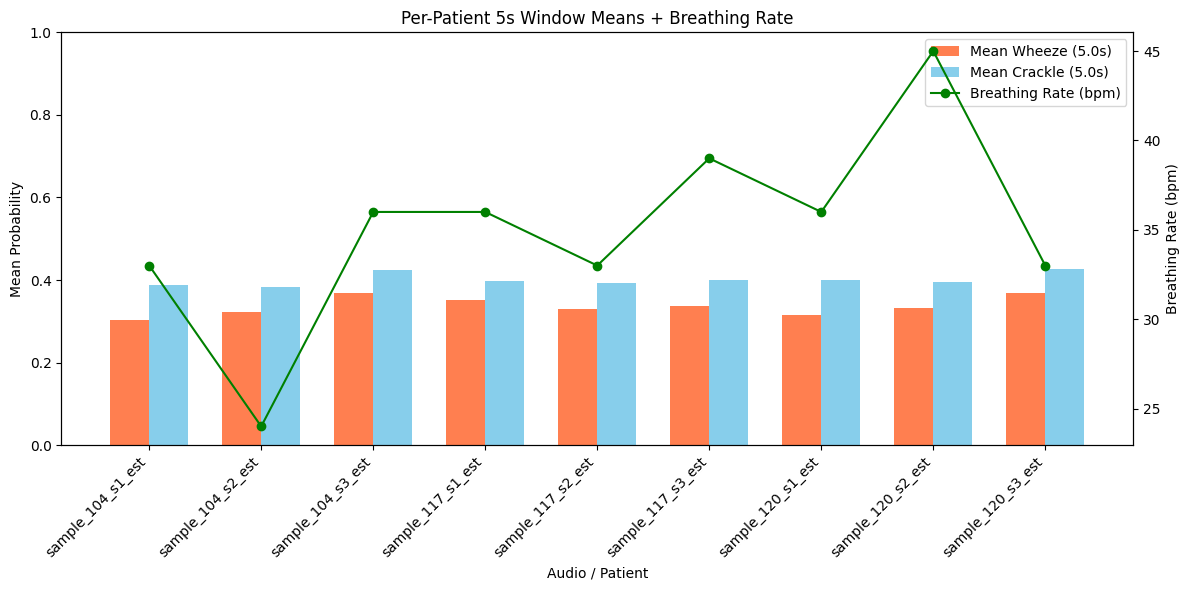

Visualization saved to: /kaggle/working/pipeline_results/patient_summary_5s.png
            audio_id  breathing_rate_mean  mean_wheeze_prob  \
0  sample_104_s1_est                 33.0          0.303975   
1  sample_104_s2_est                 24.0          0.321700   
2  sample_104_s3_est                 36.0          0.369000   
3  sample_117_s1_est                 36.0          0.351775   
4  sample_117_s2_est                 33.0          0.329425   
5  sample_117_s3_est                 39.0          0.338275   
6  sample_120_s1_est                 36.0          0.314175   
7  sample_120_s2_est                 45.0          0.333300   
8  sample_120_s3_est                 33.0          0.367950   

   mean_crackle_prob  num_windows  
0           0.387900            4  
1           0.384025            4  
2           0.425125            4  
3           0.396825            4  
4           0.392025            4  
5           0.400200            4  
6           0.400250            4  
7

In [7]:
# Visualizations and summary tables (per patient, 5s windows)
def load_reasoning_df():
    if "reasoning_df" in globals() and isinstance(reasoning_df, pd.DataFrame) and not reasoning_df.empty:
        return reasoning_df
    reasoning_json = Path(PIPELINE_OUTPUT) / "reasoning_summary.json"
    if reasoning_json.exists():
        try:
            return pd.read_json(reasoning_json)
        except Exception as e:
            print("Failed to read reasoning_summary.json:", e)
            return None
    print("No reasoning summary found. Run the reasoning summary cell first.")
    return None

def plot_patient_summary(df, output_dir, window_seconds=5.0):
    if df is None or df.empty:
        print("No patient summaries to visualize")
        return

    audio_ids = df["audio_id"].fillna("unknown").astype(str).tolist()
    wheeze_mean = df["mean_wheeze_prob"].fillna(0).astype(float).tolist()
    crackle_mean = df["mean_crackle_prob"].fillna(0).astype(float).tolist()
    br_mean = df["breathing_rate_mean"].fillna(0).astype(float).tolist()

    x = np.arange(len(audio_ids))
    width = 0.35
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.bar(x - width / 2, wheeze_mean, width, label="Mean Wheeze (%ss)" % window_seconds, color="coral")
    ax1.bar(x + width / 2, crackle_mean, width, label="Mean Crackle (%ss)" % window_seconds, color="skyblue")
    ax1.set_ylabel("Mean Probability")
    ax1.set_xlabel("Audio / Patient")
    ax1.set_xticks(x)
    ax1.set_xticklabels(audio_ids, rotation=45, ha="right")
    ax1.set_ylim(0.0, 1.0)
    ax1.set_title("Per-Patient 5s Window Means + Breathing Rate")

    ax2 = ax1.twinx()
    ax2.plot(x, br_mean, color="green", marker="o", label="Breathing Rate (bpm)")
    ax2.set_ylabel("Breathing Rate (bpm)")

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plot_path = Path(output_dir) / "patient_summary_5s.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Visualization saved to:", str(plot_path))

    summary_cols = ["audio_id", "breathing_rate_mean", "mean_wheeze_prob", "mean_crackle_prob", "num_windows"]
    available = [c for c in summary_cols if c in df.columns]
    print(df[available].sort_values("audio_id").reset_index(drop=True))

reasoning_summary_df = load_reasoning_df()
plot_patient_summary(reasoning_summary_df, PIPELINE_OUTPUT, window_seconds=5.0)